# Restaurant Cuisine Classification

**Objective:** Predict a restaurant's primary cuisine from its non-text attributes (location, price, ratings, service options) using a supervised classification model.

This notebook mirrors the pipeline in `src/preprocessing.py` and `src/train.py` and walks through each step of the task:

1. Load and inspect the data
2. Preprocess: handle missing values, engineer features, encode categoricals
3. Split into train/test sets
4. Train a classification model (Random Forest, compared against a Logistic Regression baseline)
5. Evaluate with accuracy, precision, recall, F1
6. Analyze performance per cuisine and discuss challenges/biases


In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    precision_recall_fscore_support, f1_score
)

from preprocessing import clean_and_engineer, build_feature_frame, load_data

pd.set_option('display.max_columns', 50)


## 1. Load and inspect the data

In [2]:
raw = load_data('../data/Restaurant_Dataset.csv')
print(raw.shape)
raw.head()

(9551, 21)


   Restaurant ID         Restaurant Name  Country Code              City  \
0        6317637        Le Petit Souffle           162       Makati City   
1        6304287        Izakaya Kikufuji           162       Makati City   
2        6300002  Heat - Edsa Shangri-La           162  Mandaluyong City   
3        6318506                    Ooma           162  Mandaluyong City   
4        6314302             Sambo Kojin           162  Mandaluyong City   

                                             Address  \
0  Third Floor, Century City Mall, Kalayaan Avenu...   
1  Little Tokyo, 2277 Chino Roces Avenue, Legaspi...   
2  Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...   
3  Third Floor, Mega Fashion Hall, SM Megamall, O...   
4  Third Floor, Mega Atrium, SM Megamall, Ortigas...   

                                     Locality  \
0   Century City Mall, Poblacion, Makati City   
1  Little Tokyo, Legaspi Village, Makati City   
2  Edsa Shangri-La, Ortigas, Mandaluyong City   
3      SM 

In [3]:
raw.isnull().sum()[raw.isnull().sum() > 0]

Cuisines    9
dtype: int64

Only the `Cuisines` column has missing values (9 rows out of 9,551) — but it's central to this task, since it's where our target label comes from. `Average Cost for two` also has a large number of `0` entries which aren't genuine prices; we treat those as missing too and impute them during preprocessing.

In [4]:
primary_cuisine = raw['Cuisines'].dropna().apply(lambda x: x.split(',')[0].strip())
print(f"{primary_cuisine.nunique()} distinct primary cuisines")
primary_cuisine.value_counts().head(15)

119 distinct primary cuisines


Cuisines
North Indian    2992
Chinese          855
Fast Food        672
Bakery           621
Cafe             617
American         278
South Indian     262
Mithai           246
Street Food      236
Continental      235
Italian          234
Pizza            232
Mughlai          215
Ice Cream        178
Desserts         150
Name: count, dtype: int64

**Key modeling decision:** restaurants can list *multiple* cuisines (e.g. "North Indian, Chinese"). Rather than solving a multi-label problem, we classify each restaurant by its **primary (first-listed) cuisine** — a standard simplification for this dataset. But the raw label space has 119 distinct primary cuisines, most with only a handful of examples (median is far below what any model could learn reliably). We keep the 12 most frequent as explicit classes and bucket everything else into `Other`. This is a deliberate trade-off, documented here and in `README.md`, that keeps every class learnable and evaluable.

## 2. Preprocess: missing values, feature engineering, encoding

In [5]:
df = clean_and_engineer(raw, top_n=12)
print(df.shape)
df[['Primary Cuisine', 'Cuisine Class', 'Cuisine Count', 'Average Cost for two', 'City']].head()

(9542, 24)


  Primary Cuisine Cuisine Class  Cuisine Count  Average Cost for two  \
0          French         Other              3                1100.0   
1        Japanese         Other              1                1200.0   
2         Seafood         Other              4                4000.0   
3        Japanese         Other              2                1500.0   
4        Japanese         Other              2                1500.0   

         City  
0  Other City  
1  Other City  
2  Other City  
3  Other City  
4  Other City  

Preprocessing steps applied (see `src/preprocessing.py` for the full, commented implementation):

- **Dropped** the 9 rows with no cuisine information (no label can be derived for them).
- **Engineered** `Cuisine Count` — how many cuisines a restaurant lists — since this signal would otherwise be discarded once we reduce to a single primary label.
- **Bucketed** rare primary cuisines into `Other`, and rare cities (140+ distinct values, heavily skewed toward Delhi NCR) into `Other City`, to avoid near-unique, unlearnable categories.
- **Imputed** `Average Cost for two` (with `0` treated as missing) using the median cost *within each country*, since prices aren't comparable across currencies/economies.
- **Imputed** remaining numeric fields (`Votes`, `Aggregate rating`, coordinates) with the column median, and categorical fields with `"Unknown"`.
- **Encoded** Yes/No service columns (table booking, online delivery, etc.) as 0/1, and one-hot encoded `City` and `Currency`.


In [6]:
X, y = build_feature_frame(df)
print(f'Feature matrix: {X.shape}')
print(f'Target classes ({y.nunique()}):')
y.value_counts()

Feature matrix: (9542, 42)
Target classes (13):


Cuisine Class
North Indian    2992
Other           2062
Chinese          855
Fast Food        672
Bakery           621
Cafe             617
American         278
South Indian     262
Mithai           246
Street Food      236
Continental      235
Italian          234
Pizza            232
Name: count, dtype: int64

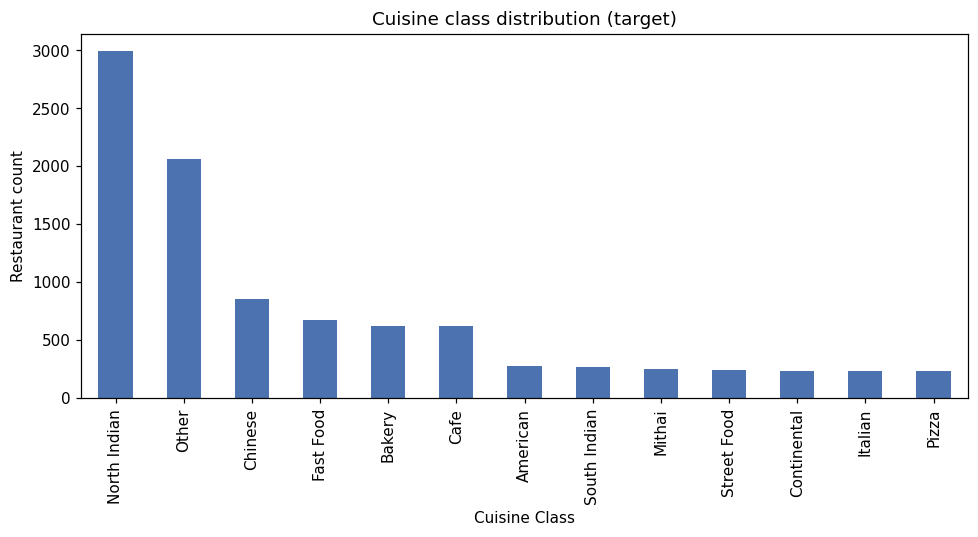

In [7]:
fig, ax = plt.subplots(figsize=(9,5))
y.value_counts().plot(kind='bar', ax=ax, color='#4C72B0')
ax.set_title('Cuisine class distribution (target)')
ax.set_ylabel('Restaurant count')
plt.tight_layout()
plt.show()

The classes are **heavily imbalanced**: `North Indian` alone accounts for roughly a third of restaurants (unsurprising, given the dataset is dominated by Delhi-NCR restaurants), while classes like `Pizza` or `Italian` have only ~230 examples. This imbalance is one of the central challenges we return to in the evaluation section.

## 3. Train/test split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

Train: (7633, 42), Test: (1909, 42)


We stratify the split on the target so every cuisine class is proportionally represented in both train and test sets — important given the imbalance above.

## 4. Train classification models

We train two models to compare:

- **Logistic Regression** — a simple, interpretable linear baseline.
- **Random Forest** — a non-linear ensemble model, better suited to the mixed numeric/categorical feature set and interactions between features (e.g. price range × city).

Both use `class_weight='balanced'`-style weighting so the models aren't purely dominated by the majority `North Indian` class.

In [9]:
log_reg = LogisticRegression(max_iter=1000, class_weight='balanced', n_jobs=-1)
log_reg.fit(X_train_scaled, y_train)
y_pred_lr = log_reg.predict(X_test_scaled)

rf = RandomForestClassifier(
    n_estimators=150, max_depth=15, min_samples_leaf=5,
    class_weight='balanced_subsample', random_state=42, n_jobs=-1
)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)

print('Logistic Regression accuracy:', accuracy_score(y_test, y_pred_lr))
print('Random Forest accuracy:      ', accuracy_score(y_test, y_pred_rf))

Logistic Regression accuracy: 0.1534834992142483
Random Forest accuracy:       0.2708224201152436


## 5. Evaluate: accuracy, precision, recall, F1

In [10]:
print('=== Random Forest ===')
print(f"Accuracy:    {accuracy_score(y_test, y_pred_rf):.3f}")
print(f"Macro F1:    {f1_score(y_test, y_pred_rf, average='macro'):.3f}")
print(f"Weighted F1: {f1_score(y_test, y_pred_rf, average='weighted'):.3f}")
print()
print(classification_report(y_test, y_pred_rf, zero_division=0))

=== Random Forest ===
Accuracy:    0.271
Macro F1:    0.259
Weighted F1: 0.275

              precision    recall  f1-score   support

    American       0.32      0.64      0.42        56
      Bakery       0.18      0.29      0.22       124
        Cafe       0.26      0.41      0.32       123
     Chinese       0.18      0.12      0.14       171
 Continental       0.16      0.66      0.26        47
   Fast Food       0.21      0.31      0.25       135
     Italian       0.14      0.28      0.19        47
      Mithai       0.18      0.49      0.27        49
North Indian       0.62      0.25      0.36       599
       Other       0.62      0.14      0.23       413
       Pizza       0.23      0.52      0.32        46
South Indian       0.11      0.23      0.15        52
 Street Food       0.16      0.40      0.23        47

    accuracy                           0.27      1909
   macro avg       0.26      0.37      0.26      1909
weighted avg       0.42      0.27      0.27      1909


We report **both** macro and weighted F1 deliberately:

- **Weighted F1** is dominated by how well the model does on `North Indian` (the majority class) — it can look reasonable even if the model is bad at every other cuisine.
- **Macro F1** treats every cuisine equally regardless of size, which better exposes weak spots on minority classes like `South Indian` or `Italian`.

The gap between the two is itself a signal of class-imbalance bias, which we dig into below.

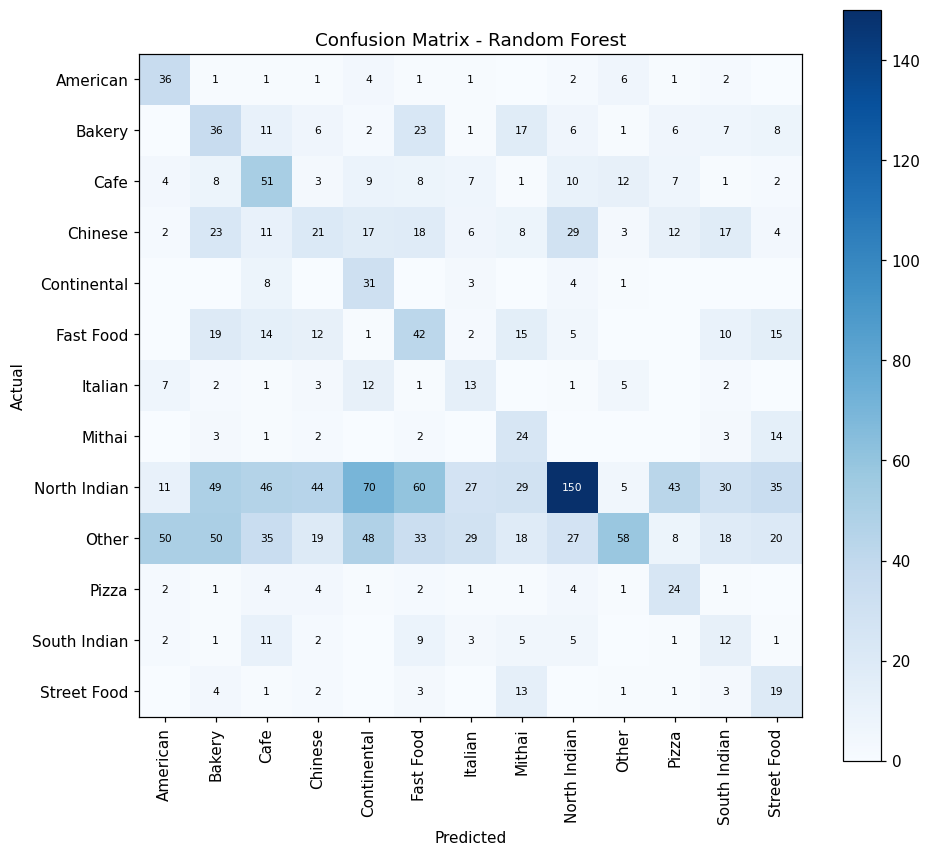

In [11]:
labels = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred_rf, labels=labels)

fig, ax = plt.subplots(figsize=(9,8))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=90)
ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix - Random Forest')
for i in range(len(labels)):
    for j in range(len(labels)):
        if cm[i,j] > 0:
            ax.text(j, i, cm[i,j], ha='center', va='center', fontsize=7,
                     color='white' if cm[i,j] > cm.max()/2 else 'black')
fig.colorbar(im)
plt.tight_layout()
plt.show()

## 6. Per-cuisine performance analysis, challenges and biases

In [12]:
precision, recall, f1, support = precision_recall_fscore_support(y_test, y_pred_rf, labels=labels, zero_division=0)
per_class = pd.DataFrame({
    'cuisine': labels, 'precision': precision, 'recall': recall,
    'f1_score': f1, 'support': support
}).sort_values('f1_score')
per_class

         cuisine  precision    recall  f1_score  support
3        Chinese   0.176471  0.122807  0.144828      171
11  South Indian   0.113208  0.230769  0.151899       52
6        Italian   0.139785  0.276596  0.185714       47
1         Bakery   0.182741  0.290323  0.224299      124
9          Other   0.623656  0.140436  0.229249      413
12   Street Food   0.161017  0.404255  0.230303       47
5      Fast Food   0.207921  0.311111  0.249258      135
4    Continental   0.158974  0.659574  0.256198       47
7         Mithai   0.183206  0.489796  0.266667       49
2           Cafe   0.261538  0.414634  0.320755      123
10         Pizza   0.233010  0.521739  0.322148       46
8   North Indian   0.617284  0.250417  0.356295      599
0       American   0.315789  0.642857  0.423529       56

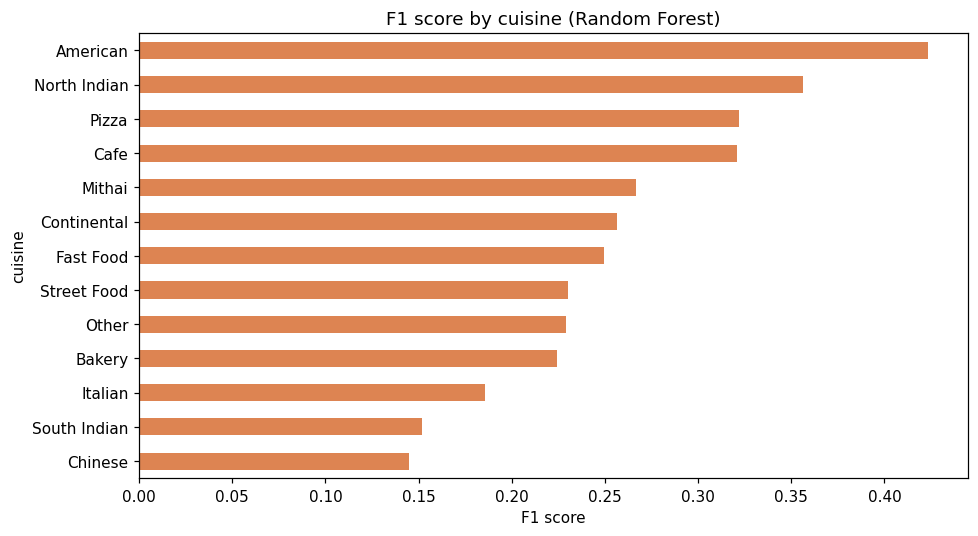

In [13]:
fig, ax = plt.subplots(figsize=(9,5))
per_class.set_index('cuisine')['f1_score'].plot(kind='barh', ax=ax, color='#DD8452')
ax.set_title('F1 score by cuisine (Random Forest)')
ax.set_xlabel('F1 score')
plt.tight_layout()
plt.show()

### Key findings

**1. The model does best on classes with either strong signal or a clear "outlier" price/location profile.**
`North Indian` (the majority class, benefiting from sheer volume) and niche categories like `American`/`Pizza` (which tend to cluster in specific cities and price bands) are the easiest to identify.

**2. The model struggles most on cuisines that share the same city/price/rating profile as others.**
`South Indian`, `Chinese`, `Italian`, and `Bakery` restaurants show up across the same price ranges and cities as many other cuisines in this dataset, so with no text features (restaurant name, menu items, review text), the model has little to distinguish them on — this is a **feature limitation**, not just a modeling one.

**3. Class imbalance biases the model toward the majority class unless corrected.**
Without class-weighting, the model can reach a *higher raw accuracy* by defaulting toward `North Indian` for ambiguous cases, while performing poorly on every minority cuisine (see the gap between accuracy, weighted F1, and macro F1 above). This is a classic accuracy-vs-fairness trade-off: we chose `class_weight='balanced_subsample'` to keep the model from ignoring minority cuisines, at some cost to raw accuracy.

**4. Geographic bias.** Because ~85% of restaurants are in the Delhi-NCR region (New Delhi, Gurgaon, Noida), the model's notion of what predicts, say, `Continental` or `Italian` is learned almost entirely from Indian metro dining patterns and may not generalize to restaurants in other countries/cities in the dataset (or beyond it).

**5. Ceiling from available features.** The strongest available signals — price range, average cost, votes, rating — describe restaurant *quality and positioning*, not necessarily *cuisine*. Two 4.2-star, mid-priced restaurants in Gurgaon could easily be an Italian bistro or a North Indian dhaba; nothing in the tabular features distinguishes them. The single biggest lever for improving this model would be adding **text features** (restaurant name tokens, or menu/review text), which are far more directly informative about cuisine than location/price/rating metadata.


## 7. Feature importance

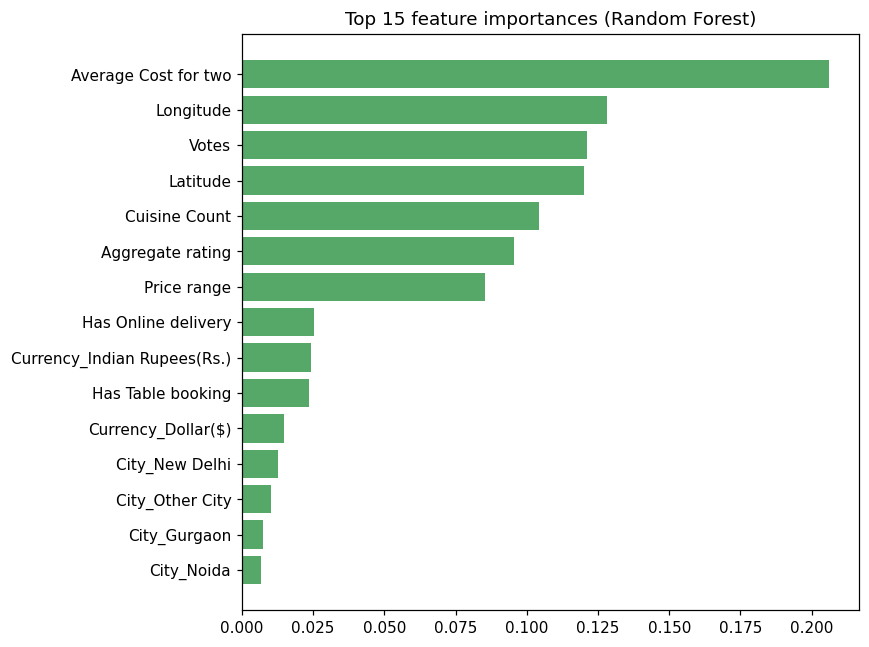

In [14]:
importances = rf.feature_importances_
idx = np.argsort(importances)[-15:]
fig, ax = plt.subplots(figsize=(8,6))
ax.barh(range(len(idx)), importances[idx], color='#55A868')
ax.set_yticks(range(len(idx)))
ax.set_yticklabels([X.columns[i] for i in idx])
ax.set_title('Top 15 feature importances (Random Forest)')
plt.tight_layout()
plt.show()

## Summary

- Built an end-to-end pipeline: cleaning, feature engineering (primary cuisine extraction, cuisine-count, long-tail bucketing), encoding, train/test split, model training, and evaluation.
- Compared Logistic Regression against Random Forest; Random Forest performs substantially better on this feature set.
- Reported accuracy alongside macro/weighted precision, recall, and F1 to surface — not hide — class-imbalance effects.
- Identified concrete challenges: heavy class imbalance, geographic concentration in Delhi-NCR, and a hard ceiling imposed by the lack of text-based (name/menu/review) features, which are likely far more predictive of cuisine than location or price.
- Next steps for improving this model are listed in `README.md` (e.g., incorporating restaurant name as a text feature via TF-IDF, gathering more balanced data for underrepresented cuisines, or reframing as multi-label classification over the full `Cuisines` field).
